# Notebook 5 — Results Tracking
Collects privacy & utility metrics from all stages. `fitness_level` is the **only** sensitive attribute.

In [1]:
import pandas as pd
import numpy as np
import json, os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../results', exist_ok=True)
print('✅ Libraries imported')

✅ Libraries imported


In [2]:
fitness_classes   = ['fit', 'moderately_fit', 'unfit']
quasi_identifiers = ['age', 'region', 'activity']


def tvd(p, q):
    """Total Variation Distance for categorical distributions."""
    keys = q.index
    p_a = p.reindex(keys, fill_value=0)
    return 0.5 * sum(abs(p_a[i] - q[i]) for i in keys)


def track_stage(df, stage_name, quasi_ids=None):
    """Compute metrics for one stage. fitness_level is the ONLY sensitive attribute."""
    if quasi_ids is None:
        quasi_ids = quasi_identifiers

    group_sizes = df.groupby(quasi_ids).size()

    metrics = {
        'stage': stage_name,
        'timestamp': datetime.now().isoformat(),
        'dataset_stats': {
            'total_records': len(df),
            'total_columns': len(df.columns),
            'columns': list(df.columns)
        },
        'group_analysis': {
            'total_groups': int(len(group_sizes)),
            'min_group_size': int(group_sizes.min()),
            'max_group_size': int(group_sizes.max()),
            'mean_group_size': float(group_sizes.mean()),
            'median_group_size': float(group_sizes.median()),
            'std_group_size': float(group_sizes.std())
        }
    }

    if 'fitness_level' in df.columns:
        diversity = df.groupby(quasi_ids)['fitness_level'].nunique()
        metrics['fitness_level_analysis'] = {
            'value_counts': df['fitness_level'].value_counts().to_dict(),
            'distribution': df['fitness_level'].value_counts(normalize=True).round(4).to_dict(),
            'diversity_per_group': {
                'min': int(diversity.min()),
                'max': int(diversity.max()),
                'mean': float(diversity.mean())
            }
        }

    return metrics

print('✅ Tracking function defined')

✅ Tracking function defined


In [3]:
df_original = pd.read_csv('../data/raw_fitness_data.csv')
original_metrics = track_stage(df_original, 'original')
print(f'✅ Original: {original_metrics["dataset_stats"]["total_records"]} records, {original_metrics["group_analysis"]["total_groups"]} groups')

✅ Original: 7000 records, 1001 groups


In [4]:
df_k = pd.read_csv('../data/k_anonymized.csv')
k_metrics = track_stage(df_k, 'k_anonymity')

k_value = 5
gs_k = df_k.groupby(quasi_identifiers).size()
k_viol = int((gs_k < k_value).sum())
fl_div_k = df_k.groupby(quasi_identifiers)['fitness_level'].nunique()

k_metrics['k_anonymity_metrics'] = {
    'k_value': k_value,
    'violations': k_viol,
    'violation_rate': float(k_viol / len(gs_k)),
    'data_loss_percent': float((len(df_original) - len(df_k)) / len(df_original) * 100),
    'sensitive_attribute': 'fitness_level',
    'fitness_level_l_violations': int((fl_div_k < 3).sum())
}
print(f'✅ K-Anonymity tracked: {k_viol} violations, data loss {k_metrics["k_anonymity_metrics"]["data_loss_percent"]:.2f}%')

✅ K-Anonymity tracked: 7 violations, data loss 0.00%


In [5]:
df_l = pd.read_csv('../data/l_diverse.csv')
l_metrics = track_stage(df_l, 'l_diversity')

l_value = 3
div_l = df_l.groupby(quasi_identifiers)['fitness_level'].nunique()
l_viol = int((div_l < l_value).sum())

l_metrics['l_diversity_metrics'] = {
    'l_value': l_value,
    'violations': l_viol,
    'violation_rate': float(l_viol / len(div_l)),
    'data_loss_percent': float((len(df_original) - len(df_l)) / len(df_original) * 100),
    'sensitive_attribute': 'fitness_level'
}
print(f'✅ L-Diversity tracked: {l_viol} violations')

✅ L-Diversity tracked: 8 violations


In [6]:
df_t = pd.read_csv('../data/t_close_anonymized.csv')
t_metrics = track_stage(df_t, 't_closeness')

t_threshold = 0.25
pop_fl = df_original['fitness_level'].value_counts(normalize=True).reindex(['fit', 'moderately_fit', 'unfit'], fill_value=0)

t_viol = 0
tvd_vals = []
for _, gd in df_t.groupby(quasi_identifiers):
    gd_dist = gd['fitness_level'].value_counts(normalize=True).reindex(['fit', 'moderately_fit', 'unfit'], fill_value=0)
    d = tvd(gd_dist, pop_fl)
    tvd_vals.append(d)
    if d > t_threshold:
        t_viol += 1

t_metrics['t_closeness_metrics'] = {
    't_threshold': t_threshold,
    'metric': 'TVD (categorical)',
    'sensitive_attribute': 'fitness_level',
    'violations': t_viol,
    'violation_rate': float(t_viol / len(tvd_vals)),
    'mean_tvd': float(np.mean(tvd_vals)),
    'data_loss_percent': float((len(df_original) - len(df_t)) / len(df_original) * 100)
}
print(f'✅ T-Closeness tracked: {t_viol} violations, mean TVD {np.mean(tvd_vals):.4f}')

✅ T-Closeness tracked: 49 violations, mean TVD 0.2617


In [7]:
all_results = {
    'project': 'Privacy-Preserving Fitness Data — fitness_level as sensitive attribute',
    'timestamp': datetime.now().isoformat(),
    'stages': {
        'original':    original_metrics,
        'k_anonymity': k_metrics,
        'l_diversity': l_metrics,
        't_closeness': t_metrics
    },
    'summary': {
        'records_original': len(df_original),
        'records_final':    len(df_t),
        'total_data_loss_percent': float((len(df_original) - len(df_t)) / len(df_original) * 100)
    }
}

with open('../results/privacy_metrics_complete.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print('✅ Saved: ../results/privacy_metrics_complete.json')
print(f"\nSummary: {all_results['summary']}")

✅ Saved: ../results/privacy_metrics_complete.json

Summary: {'records_original': 7000, 'records_final': 7000, 'total_data_loss_percent': 0.0}


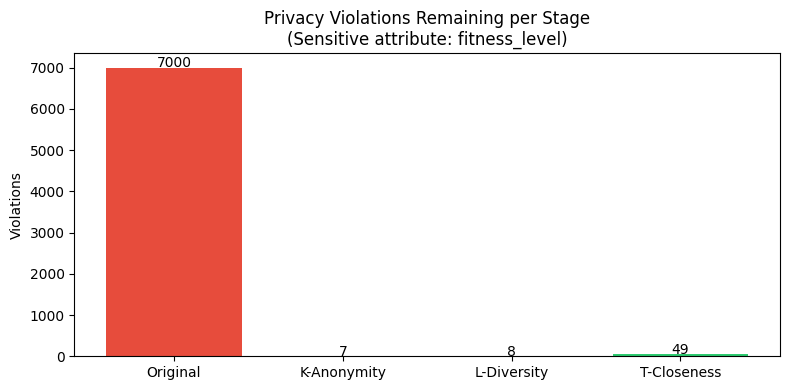

✅ Visualization saved


In [8]:
import matplotlib.pyplot as plt

stages = ['Original', 'K-Anonymity', 'L-Diversity', 'T-Closeness']
violations = [
    len(df_original),   # proxy: all records are vulnerable in raw data
    k_viol,
    l_viol,
    t_viol
]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(stages, violations, color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'])
ax.set_title('Privacy Violations Remaining per Stage\n(Sensitive attribute: fitness_level)')
ax.set_ylabel('Violations')
for bar, val in zip(bars, violations):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha='center')
plt.tight_layout()
plt.savefig('../results/05_violations_per_stage.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Visualization saved')